## データの整理
### AISによる予測データ
lat, lonの範囲
LatIdxMax = 1500
LatIdxMin = 600
LonIdxMax = 4500
LonIdxMin = 3510<br>
AIS5は-9時間のずれ<br>
AIS4はMmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount<br>
グリッド間隔：0.03333334,時間間隔：01:00:00<br>
DtIdx=Round((DateTime-#2011/1/1 00:00UTC#)/グリッド間隔)<br>
LatIdx=Round(Deg/グリッド間隔)<br>

### JCOPEのデータ
1°あたりのメッシュ数36

eas：解析値（nowcast<br>
Lat 20-1/72～50+1/72°(30*36+2=1082個)<br> 
Lon 117-1/72～150+1/72°(33*36+2=1190個)<br>

nedo：再解析値<br>
Lat 24-1/72～48+1/72° Lon 125-1/72～148+1/72°<br>

Item: U, V （Uは東向き Vは北向き 単位m/s）表層のみ 4bytes float<br>
の値を持っている。また、陸など未定義値として1e+20を使用する。<br>


In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns

## 関数の定義

In [2]:
# dummpy jcope data
# data: 1*(n+m)
def dummy_jcope_data(x0, dx, count, noise_factor, size=[10, 10]):
    data = []
    for i in range(count):
        data.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        data[i].append(0)
    return data

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data(x0, dx, omega, count, noise_factor, size=[10, 10]):
    xy = []
    sum_w = []
    for i in range(count):
        xy.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        xy[i].append(1)
        sum_w[i].append(0.00001)
    return xy, sum_w

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data2(x0, dx, omega, count, noise_factor, size=[10, 10]):
    v = []
    theta = []
    sum_w = []
    for i in range(count):
        v.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        theta.append([x0+ omega*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        v[i].append(1)
        theta[i].append(0)
        sum_w[i].append(0)
    return v, theta, sum_w

# lat lon -> mesh 
def latlon_to_mesh(lat, lon, size=[865, 831]):
    lat_range = [24-1/72, 48+1/72]
    lon_range = [125-1/72, 148+1/72]
    # lat, lon -> [lon, lat]
    grid0 = int((lon-lon_range[1])*36)
    grid1 = int((lat-lat_range[0])*36)
    if grid0<0 or grid0>size[0]: return [-1, -1]
    if grid1<0 or grid1>size[1]: return [-1, -1]
    return [grid0, grid1]

def aisIdx_to_rallon(lat_idx, lon_idx):
    return [lat_idx, lon_idx]*0.03333334

# JCOPE
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01)

# AIS(観測値) 
ais_data = dummy_ais_data(0, 0.1, 1, 100, 0.001)

## データの読み込み
easデータはうまくいかなかったので，とりあえずnedoデータでやる

In [19]:
# pathの設定
path_ais = [ fr'./data/ais/20150919\150919-{i+1}log\log' for i in range(12)]
path_jcope = [fr'./data/nedo\2015091900{i}' for i in range(24)]

# AIS (Mmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount)
ais = []
for i, p in enumerate(path_ais):
    ais2 = pd.read_csv(p+f"/japan_20150919{i*2:02}0000-20150919{i*2+1:02}5959.ais4", encoding="cp932", skiprows=[0])
    if i==0:
        ais = ais2
    else:
        ais = pd.concat([ais, ais2])

# AIS (MAP curN, curE)
date = [i for i in range(1817, 1824, 2)] + [i for i in range(1900, 1916, 2)]
ais_n_mapped = []
for i, p in enumerate(path_ais):
    ais_n_mapped.append(pd.read_csv(p+"/AisCurr201509"+str(date[i])+"N.csv", encoding="cp932",))
ais_e_mapped = []
for i, p in enumerate(path_ais):
    ais_e_mapped.append(pd.read_csv(p+"/AisCurr201509"+str(date[i])+"E.csv", encoding="cp932",))

    
# JCOPE (MAP curN, curE)
jcope_n = []
for p in path_jcope:
    jcope_n.append(pd.read_csv(p+"/N.csv", encoding="cp932",))
jcope_e = []
for p in path_jcope:
    jcope_e.append(pd.read_csv(p+"/E.csv", encoding="cp932",))

nan_map = np.array(jcope_n[0].values)*0+1

### データの確認

AIS N:(866, 831)
AIS E:(866, 831)
JCOPE N:(865, 831)
JCOPE E:(865, 831)


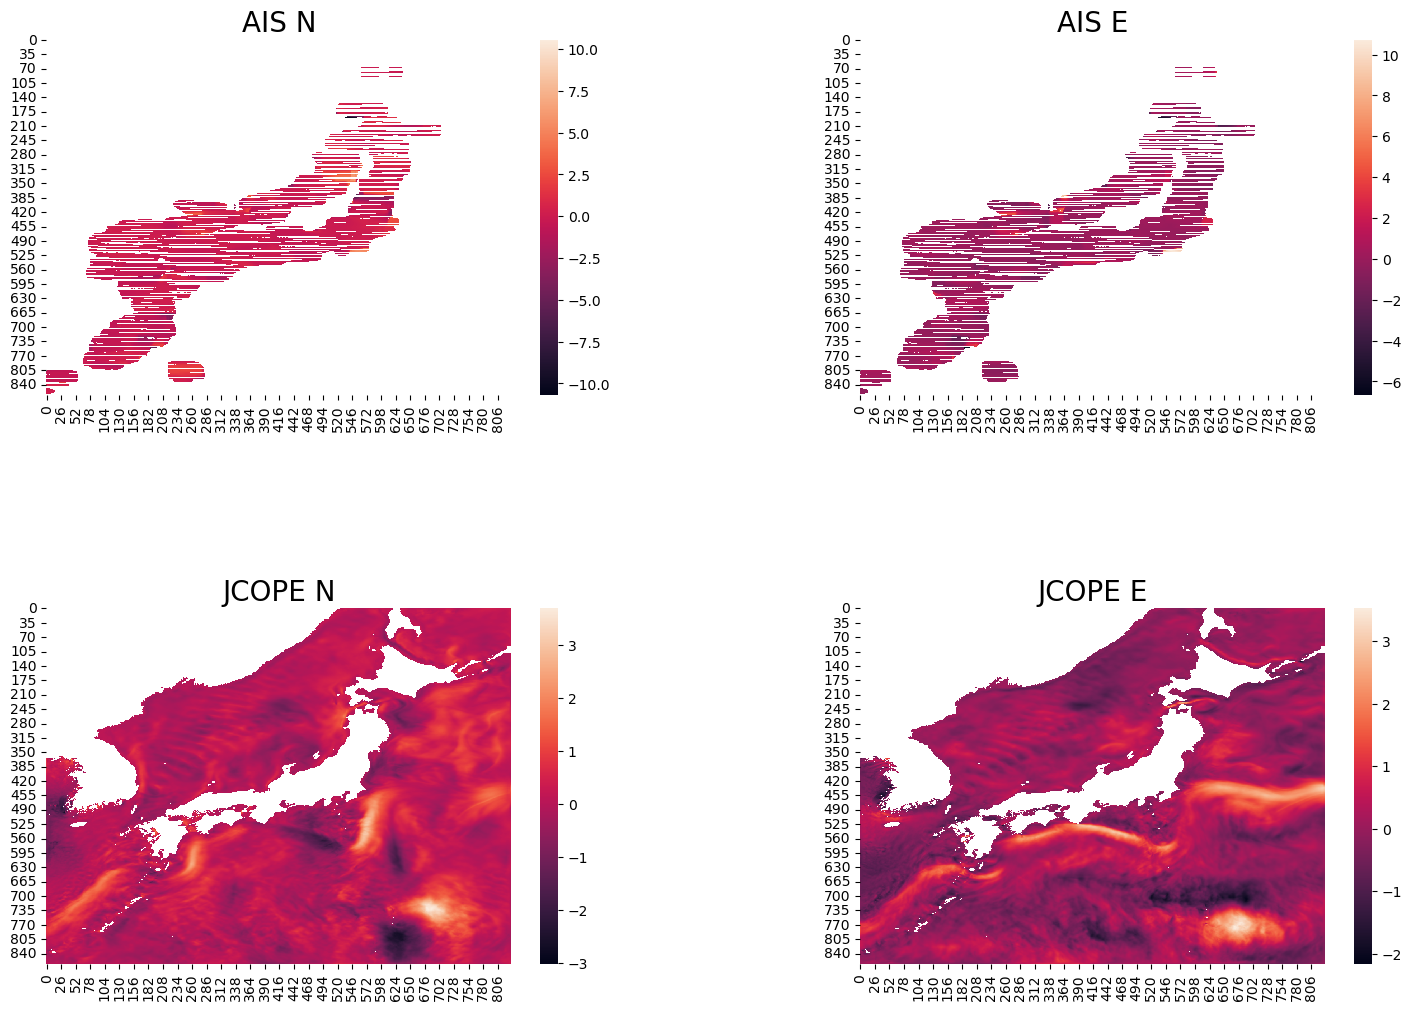

,Mmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount
0,209225000,41319,1253,4647,144.000000,1.401389e-07,2.000000
1,209225000,41319,1253,4648,144.000002,1.273990e-08,11.000000
2,209225000,41319,1254,4648,323.999994,1.439823e-01,32.000005
3,209225000,41319,1254,4649,324.000001,5.235720e-03,44.000018
4,209225000,41319,1255,4649,324.000000,1.151859e-01,2.000000


In [4]:
datas = [ais_n_mapped[1], ais_e_mapped[1], jcope_n[1], jcope_e[1]]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

ais.head()

AIS N:(865, 831)


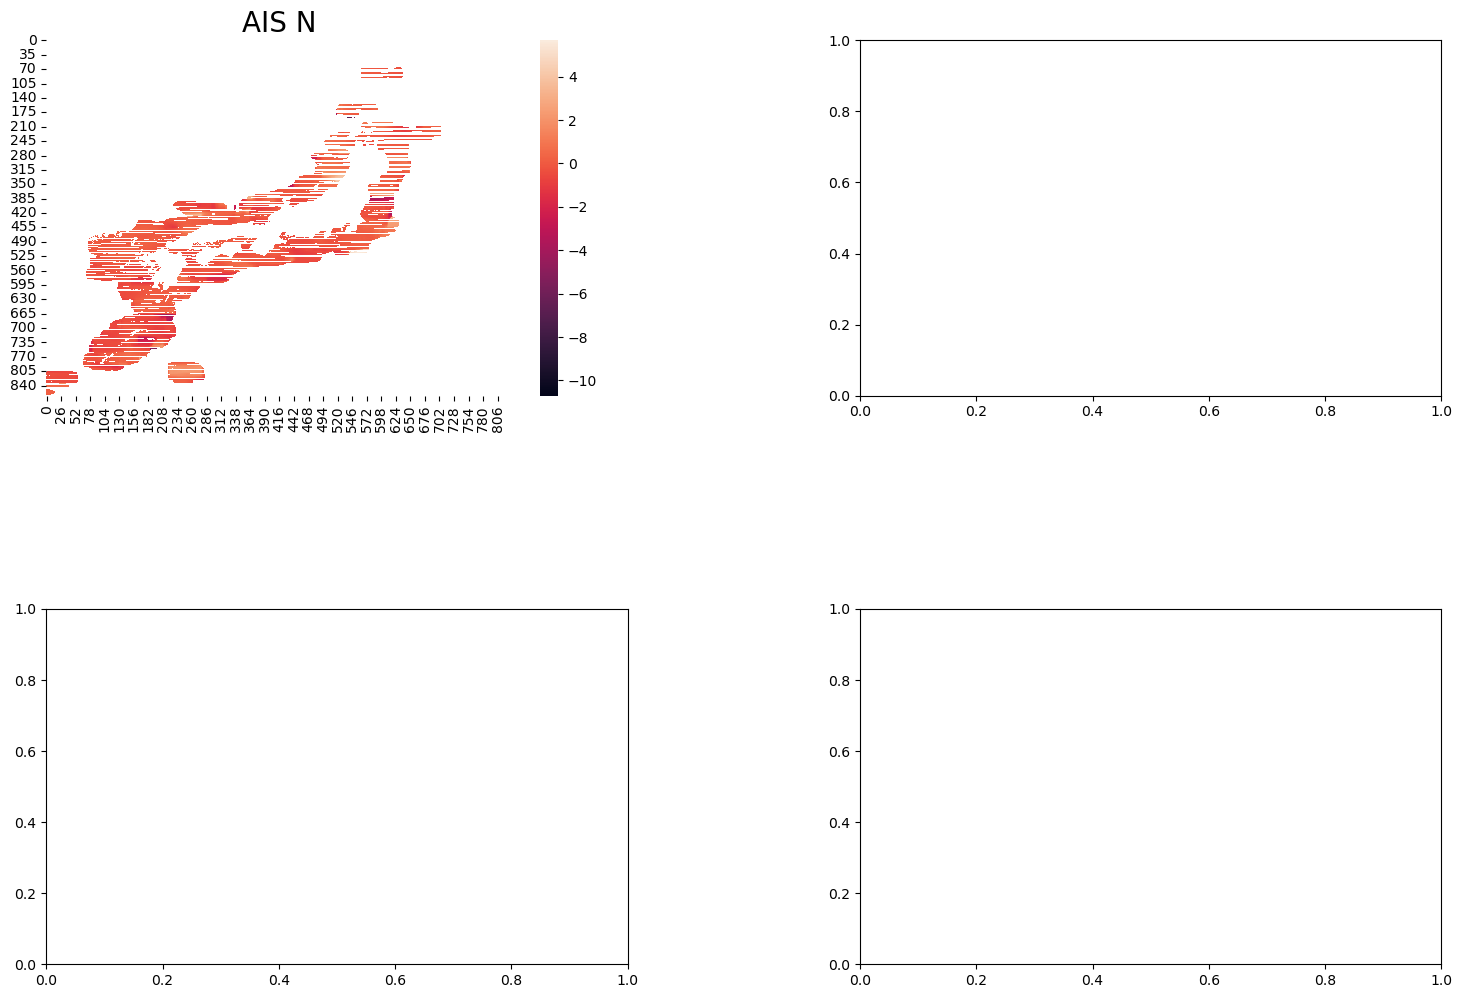

In [17]:
datas = [ais_n_mapped[1], ais_e_mapped[1], jcope_n[1], jcope_e[1]]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
i=0
print(f"{data_names[i]}:{data.shape}")
a, b = plot_place[i]
axes[a, b].set_title(data_names[i], fontsize=20)
axes[a, b].set_xlim(0, 1082)
axes[a, b].set_ylim(0, 1090)
res = np.array(datas[0].values)[0:865]*(np.array(datas[2].values)*0+1)
sns.heatmap(res, ax=axes[a, b])
plt.show()

In [5]:
# 各船のデータ数
pd.value_counts(ais['Mmsi'])

431600641    377
431100945    373
431004083    358
431006385    353
311595000    345
            ... 
259002000      1
413465360      1
413442920      1
413378260      1
311033400      1
Name: Mmsi, Length: 3037, dtype: int64

In [6]:
# 時刻データ (3hr分)
# pd.value_counts(ais['DtIdx'])
set(ais['DtIdx'].values)

{41319,
 41320,
 41321,
 41322,
 41323,
 41324,
 41325,
 41326,
 41327,
 41328,
 41329,
 41330,
 41331,
 41332,
 41333,
 41334,
 41335,
 41336,
 41337,
 41338,
 41339,
 41340,
 41341,
 41342,
 41343}

<Axes: xlabel='LatIdx', ylabel='LonIdx'>

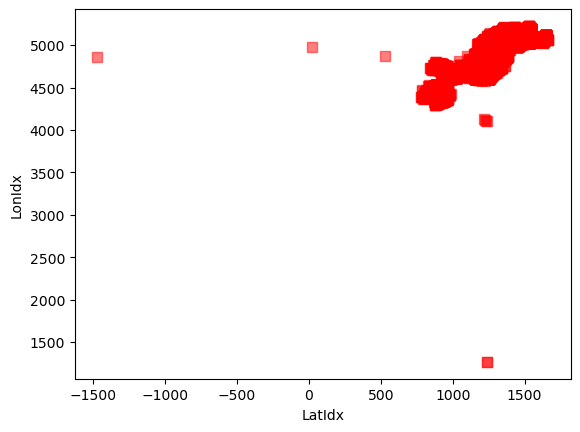

In [7]:
# データの位置
ais.plot.scatter(x='LatIdx', y='LonIdx',
                marker='s', c='r', s=50, alpha=0.5)

### データの整理

In [8]:
# 指定した範囲内のlat lonだけ使う
lat_range = [24-1/72, 48+1/72]
lon_range = [125-1/72, 148+1/72]
ais2 = ais[ais['LatIdx']>=lat_range[0]*36]
ais2 = ais2[ais2['LatIdx']<=lat_range[1]*36]
ais2 = ais2[ais2['LonIdx']>=lon_range[0]*36]
ais2 = ais2[ais2['LonIdx']<=lon_range[1]*36]

# 実数値のlat, lon
ais2['lat'] = ais2['LatIdx'].values*(1/36)
ais2['lon'] = ais2['LonIdx'].values*(1/36)

# 時間の整理
min_time = min(set(ais['DtIdx'].values))
ais2['time'] = ais2['DtIdx'].values-min_time
print(f"time: {set(ais2['time'].values)}")
if (len(set(ais2['time'].values))!=25):
    print("Check data. Time exist Error.")

# 偏流の計算
cos = np.cos(ais2['ThetaDeg']*np.pi/180)
sin = np.sin(ais2['ThetaDeg']*np.pi/180)
coscos = cos**2
sinsin = sin**2
cosF = cos * ais2['F']
sinF = sin * ais2['F']
w = ais2['LineCount']
x = w*coscos*w*cosF + w*sin*cos*w*sinF
y = w*sin*cos*w*cosF + w*sinsin*w*sinF
ais2['x'] = x
ais2['y'] = y

# 分散の計算
ais2["sigma"] = 1/(2*ais2["LineCount"])

ais2.head()

time: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}


,Mmsi,DtIdx,LatIdx,LonIdx,ThetaDeg,F,LineCount,lat,lon,time,x,y,sigma
0,209225000,41319,1253,4647,144.000000,1.401389e-07,2.000000,34.805556,129.083333,0,-4.534991e-07,3.294864e-07,0.250000
1,209225000,41319,1253,4648,144.000002,1.273990e-08,11.000000,34.805556,129.111111,0,-1.247123e-06,9.060875e-07,0.045455
2,209225000,41319,1254,4648,323.999994,1.439823e-01,32.000005,34.833333,129.111111,0,1.192798e+02,-8.666185e+01,0.015625
3,209225000,41319,1254,4649,324.000001,5.235720e-03,44.000018,34.833333,129.138889,0,8.200489e+00,-5.958004e+00,0.011364
4,209225000,41319,1255,4649,324.000000,1.151859e-01,2.000000,34.861111,129.138889,0,3.727494e-01,-2.708183e-01,0.250000


<Axes: xlabel='LatIdx', ylabel='LonIdx'>

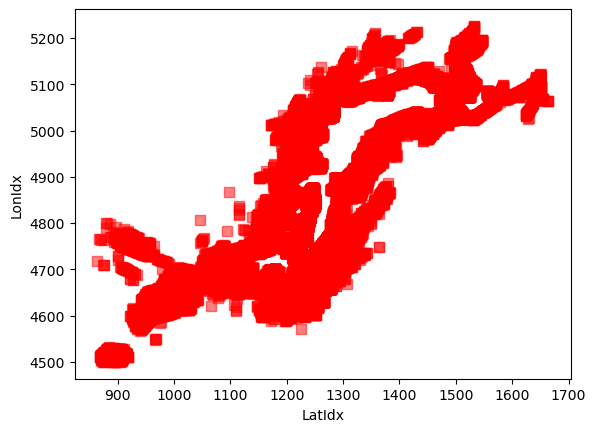

In [10]:
ais2.plot.scatter(x='LatIdx', y='LonIdx',
                marker='s', c='r', s=50, alpha=0.5)

## カルマンフィルタの設計
### 状態空間モデル
$\hat{x(t)}^{-} = A\hat{x}(t-1)$<br>
$\hat{x(t)}^{-} = J(K) + a(\hat{x}(t-1)-J(k-1))$<br>
$J(k) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
A = 
\begin{pmatrix}
   a & 0 & \cdots & 0 & (J(k)-aJ(k-1))(0, 0) \\
   0 & a & \cdots & 0 & (J(k)-aJ(k-1))(0, 1) \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & a & (J(k)-aJ(k-1))(lon-1, lat-1)\\
   0 & \cdots & 0 & 1 & 1
\end{pmatrix}
$
<br>
### 観測値
$y(t) = C\hat{x}(t)$<br>
$y(t) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
C = 
\begin{pmatrix}
   1 & 0 & \cdots & 0 & 0 \\
   0 & 1 & \cdots & 0 & 0 \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & 1 & 0\\
\end{pmatrix}
$

### とりあえず，dummyデータ

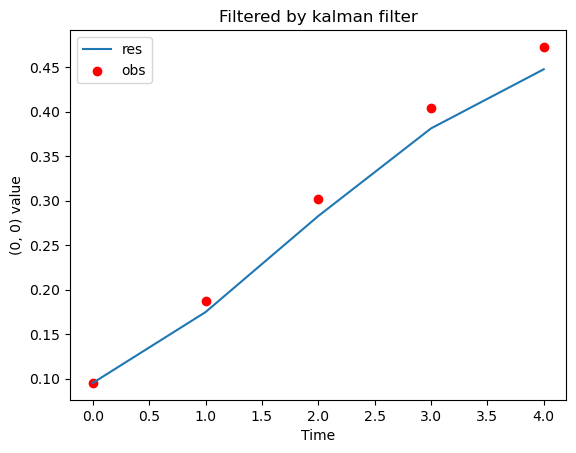

In [18]:
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def F_element(i, j, k, jcope_data):
    a = 0.5
    if i==j:
        return a
    elif i==n+m:
        residual = jcope_data[k][i]-jcope_data[k-1][i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    

n = m = 10
kf = KalmanFilter(dim_x=n+m+1, dim_z=n+m+1)

# data
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01, size=[n, m])
ais_data, ais_sum_w = dummy_ais_data(0, 0.1, 1, 100, 0.01, size=[n, m])

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_data)  for i in range(n+m+1)] for j in range(n+m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n+m+1)] for j in range(n+m+1)])

# システム雑音共分散行列, 観測雑音共分散行列, 共分散行列　TODO
kf.Q = np.eye(n+m+1)*0.01
kf.R = np.eye(n+m+1)*0.001
kf.P = np.eye(n+m+1)

# 初期位置
kf.x = np.array(jcope_data[0])


s = Saver(kf)
for i in range(1, 6):
    kf.predict()
    kf.update(np.array(ais_data[i]))
    s.save()  # 現在状態を記録する
    
s.to_array()
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
plt.title("Filtered by kalman filter")
plt.xlabel("Time")
plt.ylabel("(0, 0) value")
plt.plot(np.arange(len(s.x[:, 0])), s.x[:, 0], label='res')
plt.scatter(np.arange(len(s.x[:, 0])), s.z[:, 0], label='obs', c='r')
plt.legend()
plt.show()

### real データ

観測が同時刻にほとんどのデータはないからどうしよう？
→データがない場所は対応する箇所の誤差を十分に大きな値にして，観測を反映しないようにする


In [11]:
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def F_element(i, j, k, jcope_data):
    a = 0.5
    if i==j:
        return a
    elif i==n+m:
        residual = jcope_data[k][i]-jcope_data[k-1][i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    

n = m = 10
kf = KalmanFilter(dim_x=n+m+1, dim_z=n+m+1)

# data
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01, size=[n, m])
ais_data = 
ais_sum_w = 

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_data)  for i in range(n+m+1)] for j in range(n+m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n+m+1)] for j in range(n+m+1)])

# システム雑音共分散行列, 観測雑音共分散行列, 共分散行列　TODO
kf.Q = np.eye(n+m+1)*0.01
kf.R = np.eye(n+m+1)*0.001
kf.P = np.eye(n+m+1)

# 初期位置
kf.x = np.array(jcope_data[0])


s = Saver(kf)
for i in range(1, 6):
    kf.predict()
    y = np.array(ais_data[i])
    kf.update(y)
    s.save()  # 現在状態を記録する
    
s.to_array()
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
plt.title("Filtered by kalman filter")
plt.xlabel("Time")
plt.ylabel("(0, 0) value")
plt.plot(np.arange(len(s.x[:, 0])), s.x[:, 0], label='res')
plt.scatter(np.arange(len(s.x[:, 0])), s.z[:, 0], label='obs', c='r')
plt.legend()
plt.show()

SyntaxError: invalid syntax (4080905747.py, line 28)